[2026-08-05 14:35:14] [info     ] 计算因子，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-05 14:35:52] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-05 14:35:52] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-05 14:35:54] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-05 14:35:54] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-05 14:35:55] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-08-05 14:35:55] [info     ] ========== 数据检查 ==========
[2026-08-05 14:35:55] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg

时段,IC
2024-01-15~2024-02-08,-0.0243
2024-09-24~2024-10-08,0.0146

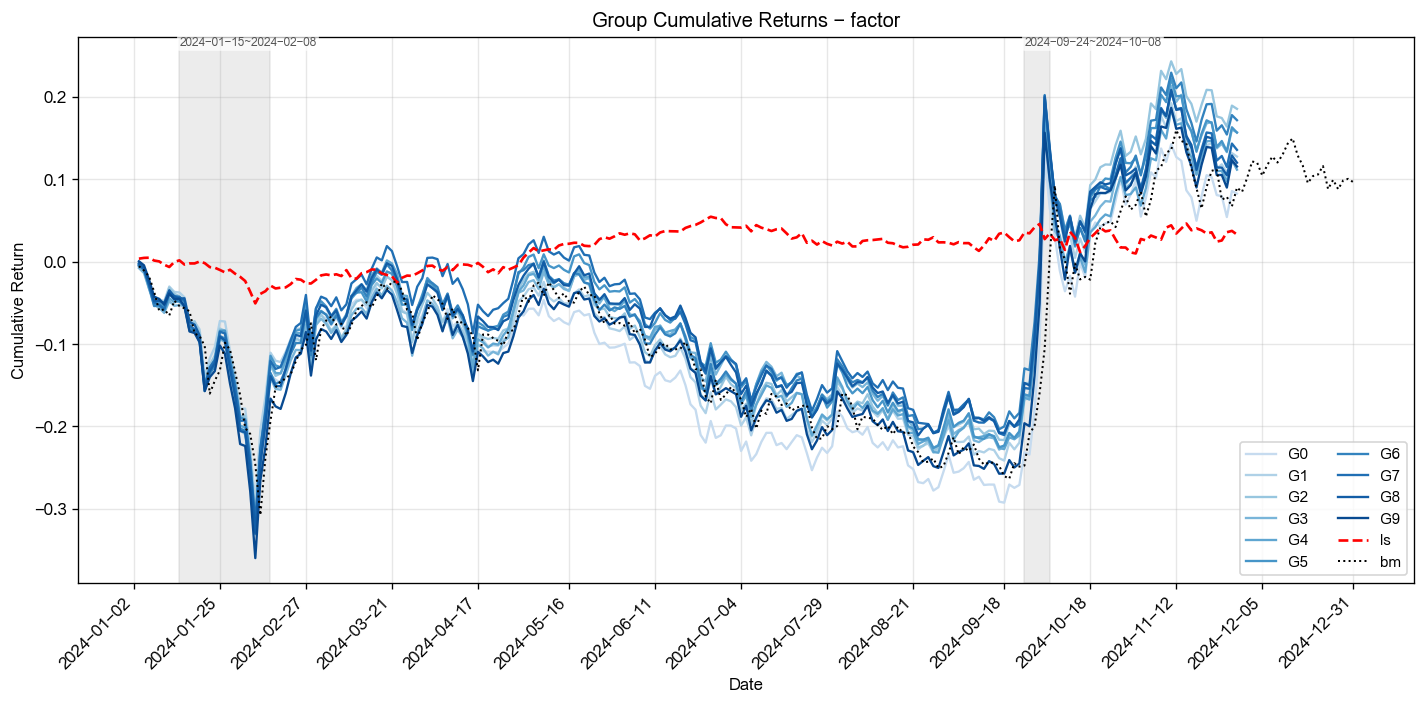
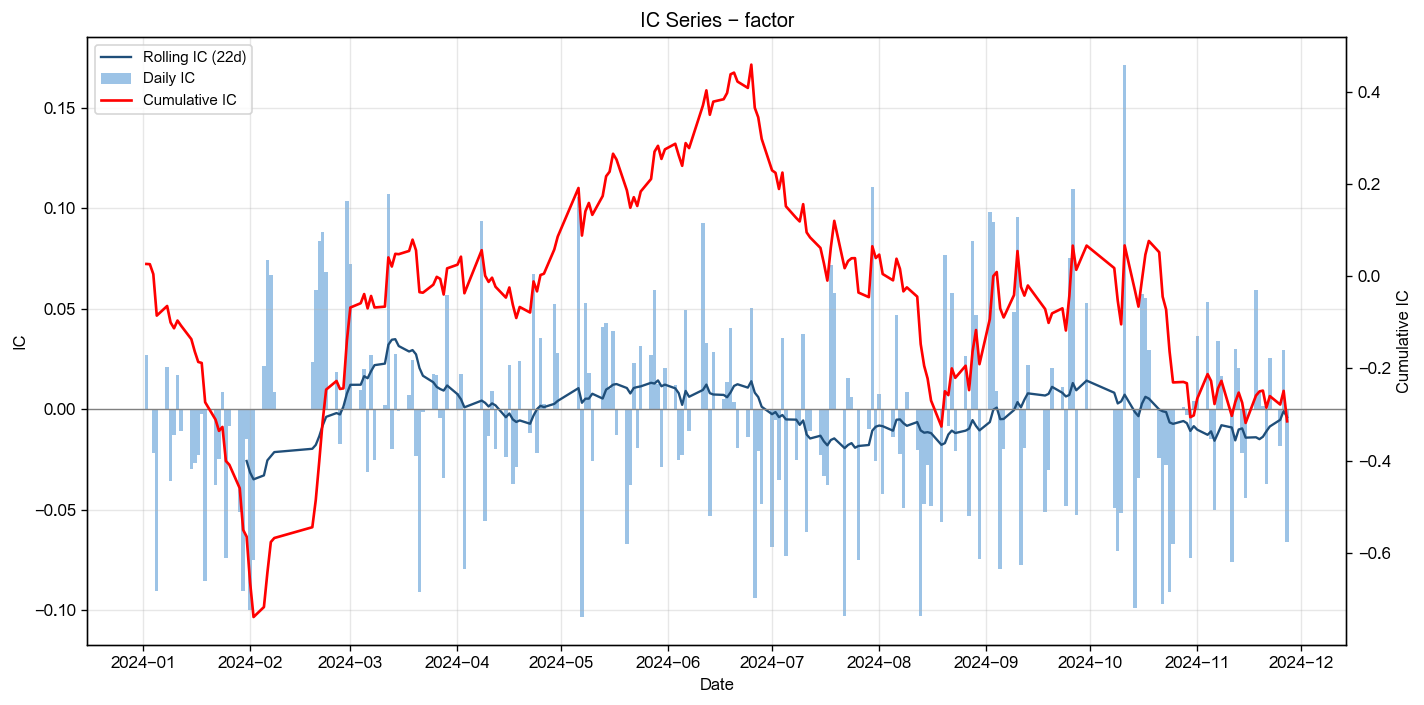
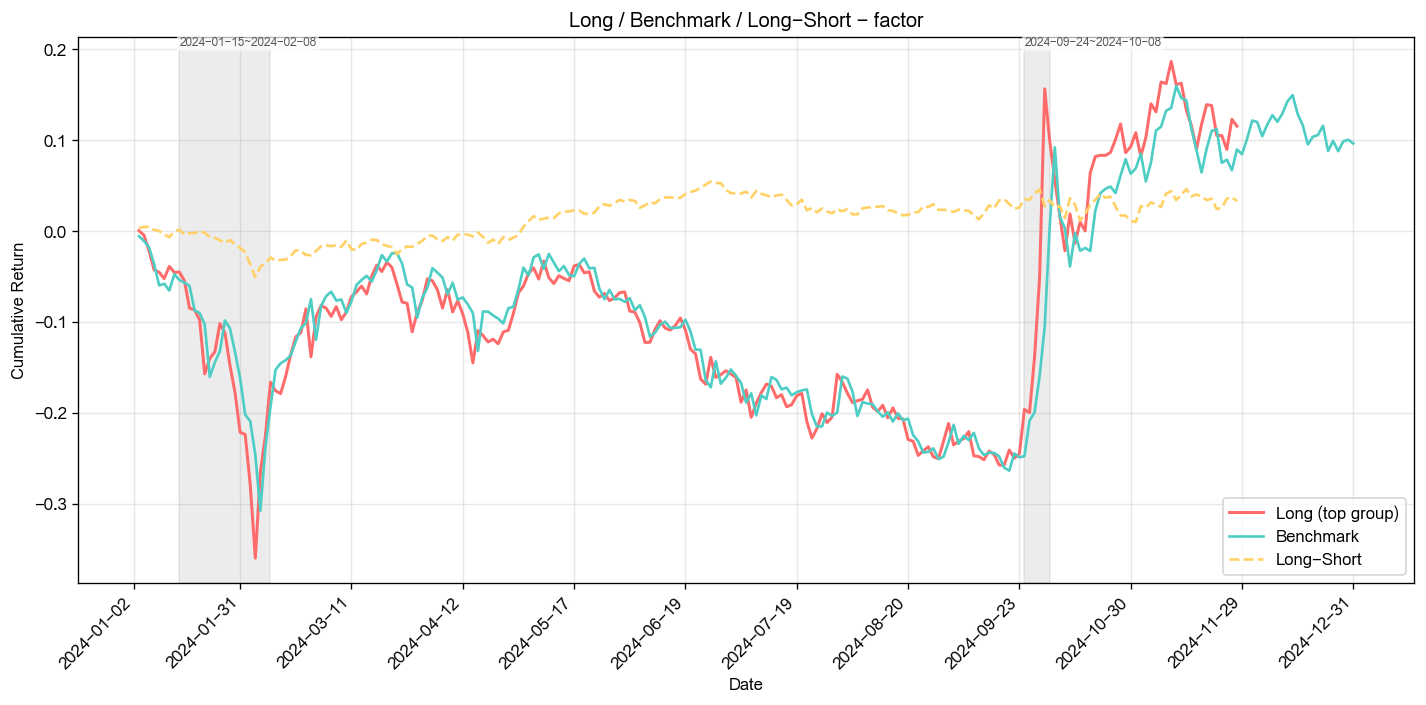
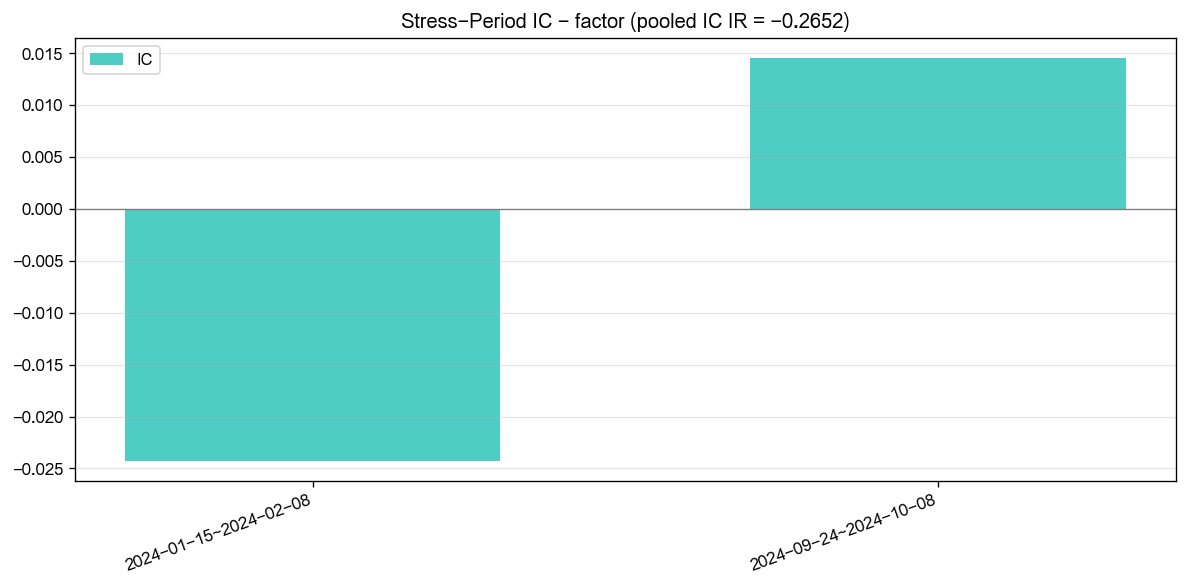
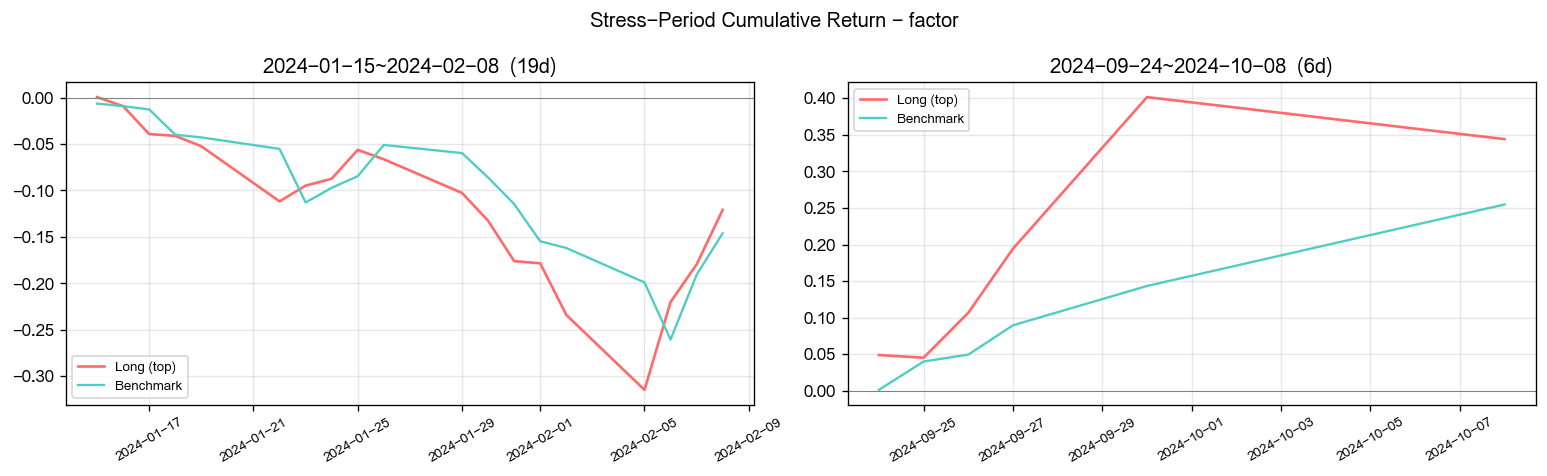

[2026-08-05 14:36:06] [info     ] ========== 因子池回归 ==========
[2026-08-05 14:36:06] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-08-05 14:36:06] [info     ] 获取收益率数据, 耗时: 0.6262 秒
[2026-08-05 14:36:06] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.0736 秒
[2026-08-05 14:36:06] [info     ] 统计 回归结果, 耗时: 0.0088 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9293,0.0447,0.0232,1.0000
2,amount,1.7199,0.0184,0.0107,1.0000
3,netflow_amount_rate_main,1.5635,0.0098,0.0063,1.0000
4,netflow_amount_main,1.5316,0.0250,0.0163,1.0000
5,gross_profit_rate_ttm,1.4954,0.0070,0.0047,1.0000
6,factor,1.4580,0.0030,0.0021,0.9000
7,net_profit_rate_ttm,1.4244,0.0038,0.0027,0.8000
8,bias_20,1.4058,0.0288,0.0205,0.9000
9,cci_14,1.3913,0.0336,0.0241,1.0000
10,pb,1.3733,0.0101,0.0073,1.0000

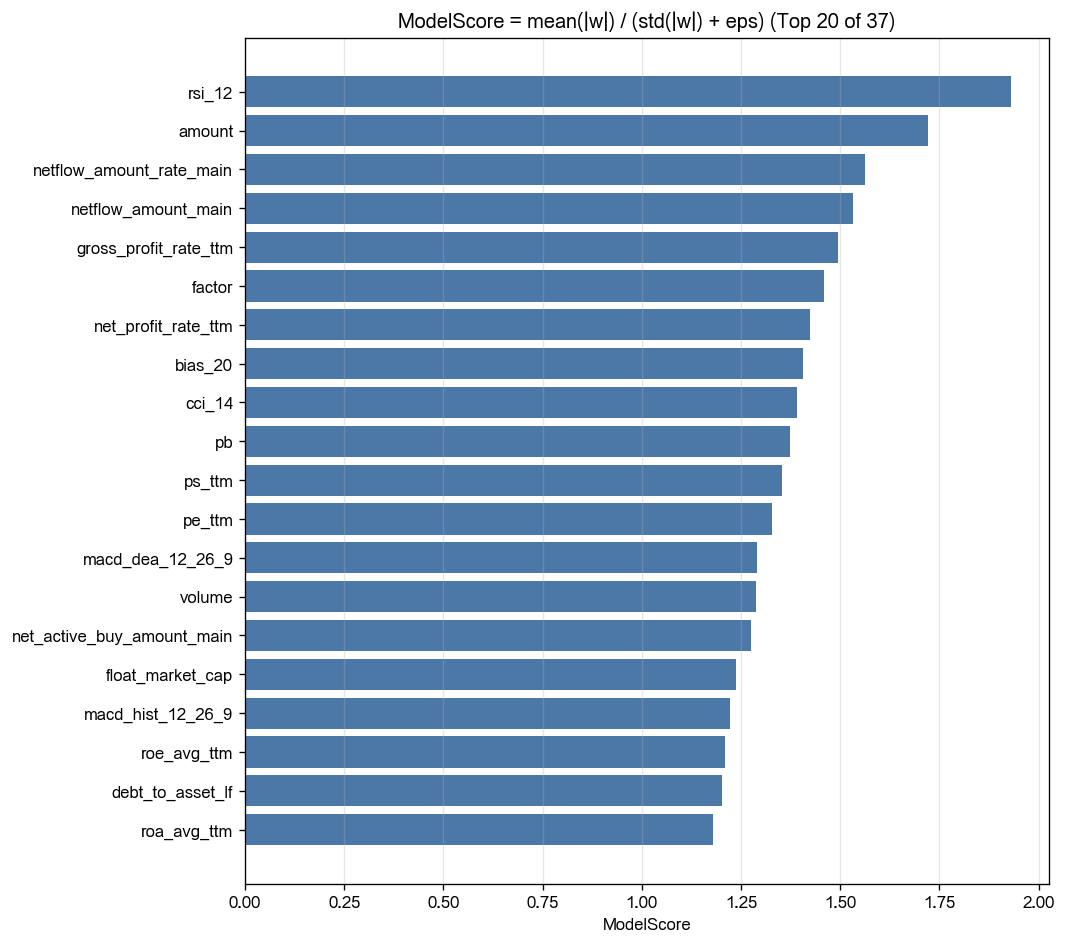
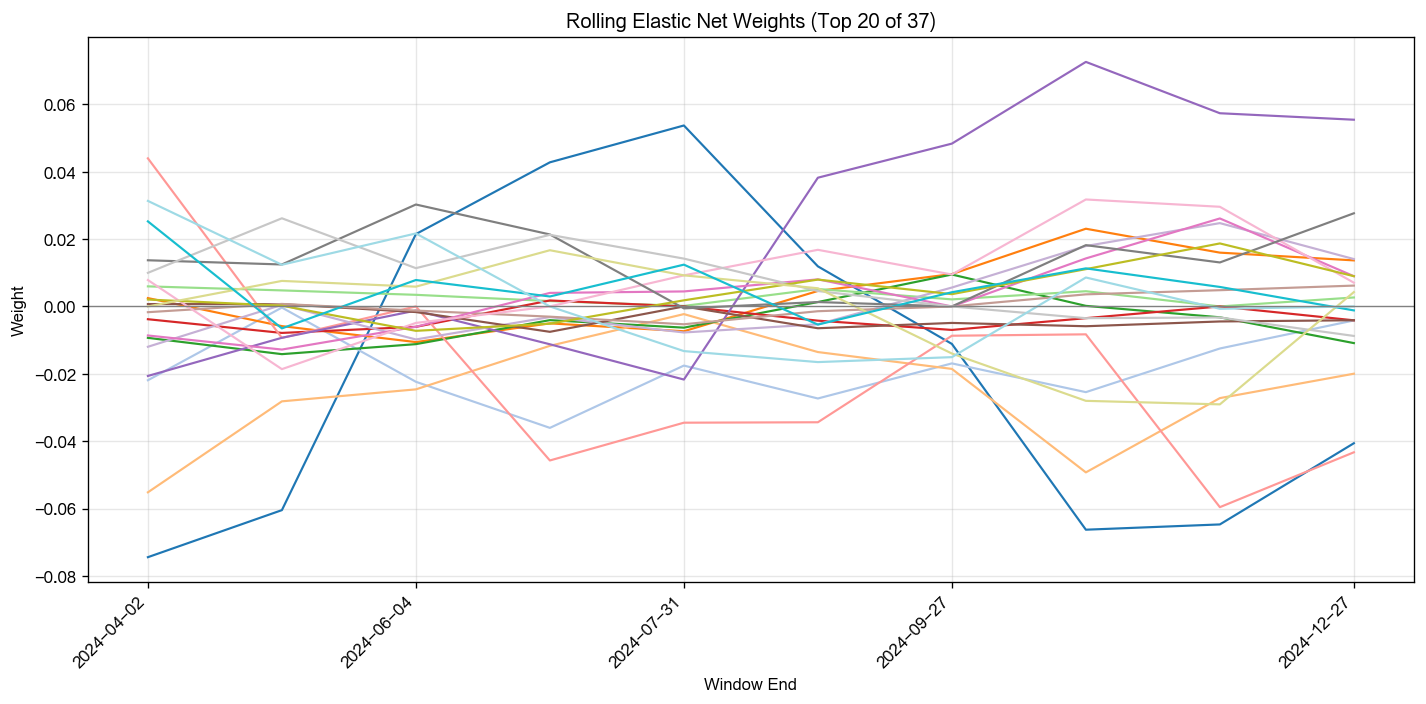
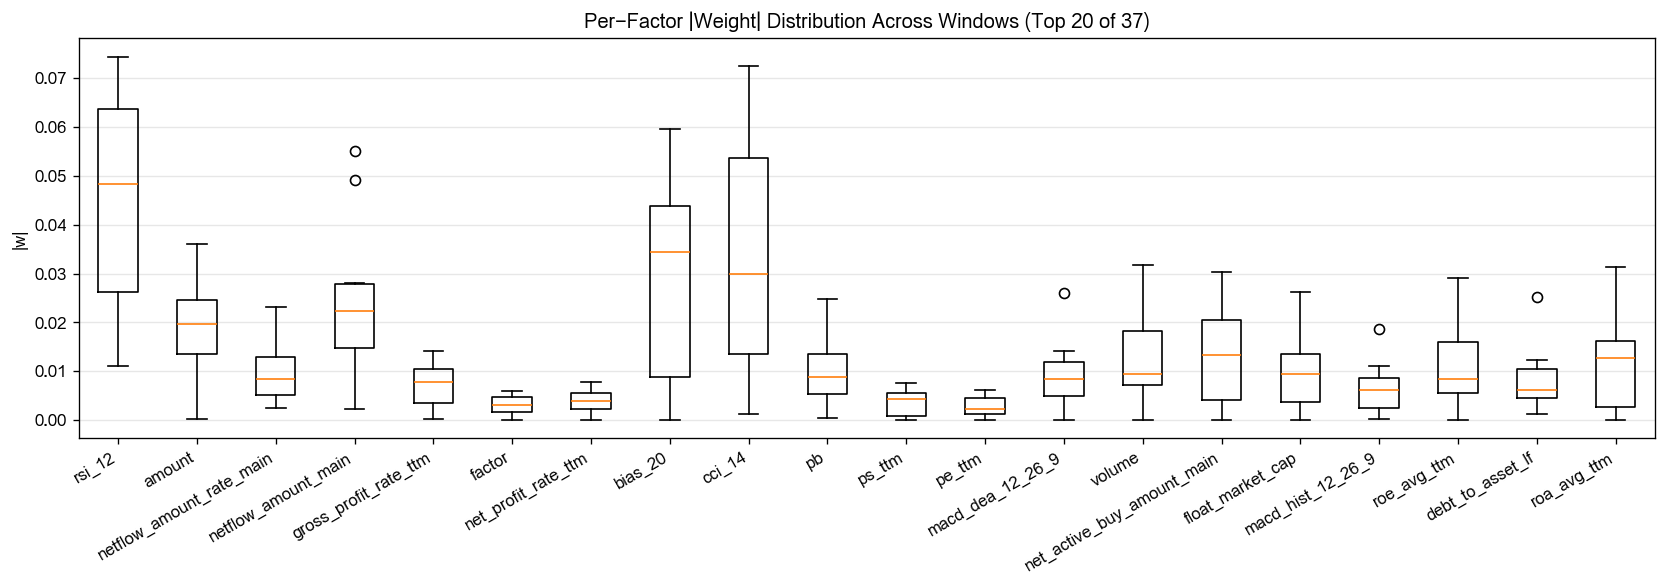
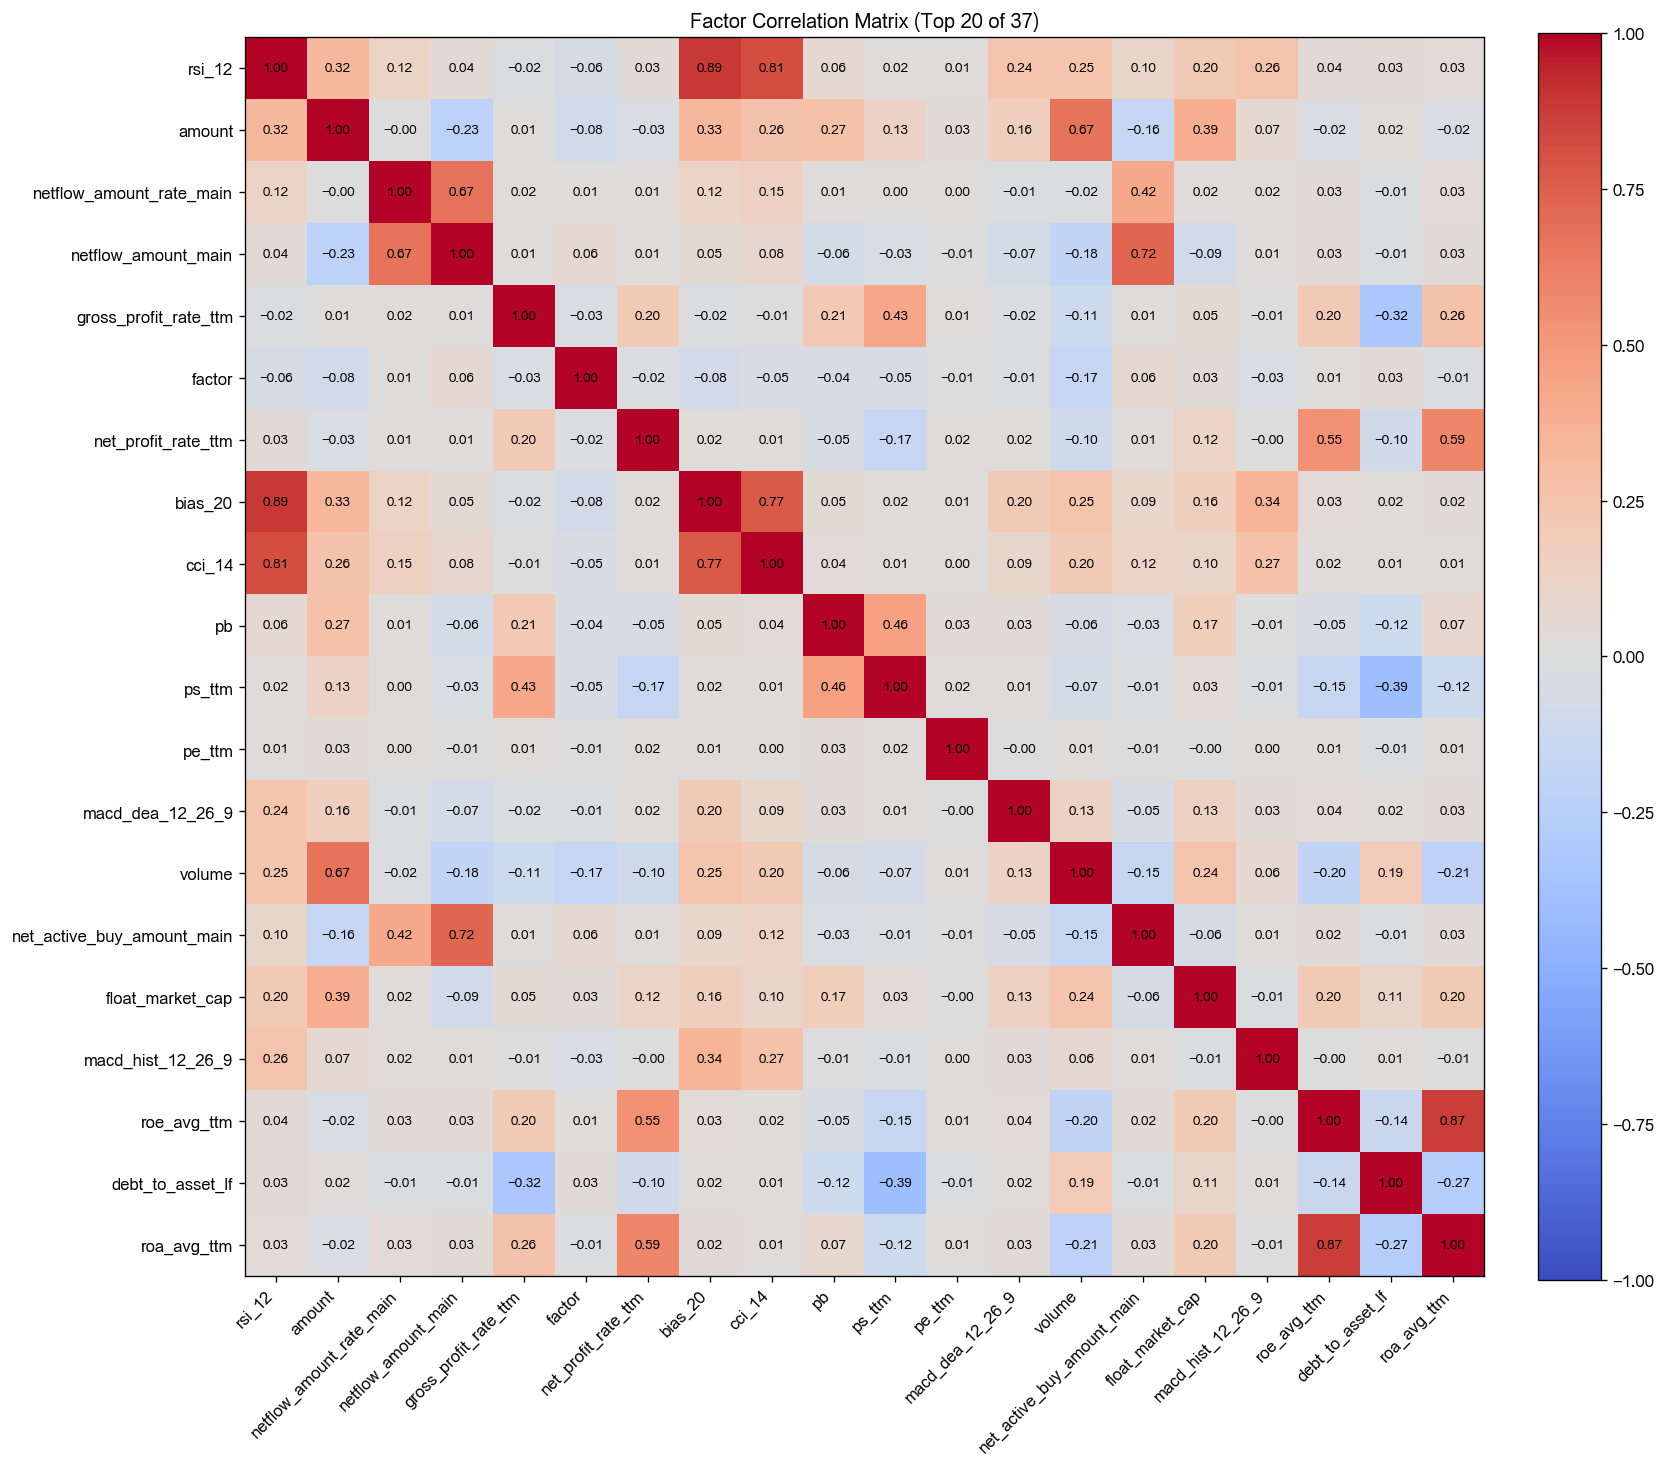

[2026-08-05 14:36:08] [warning  ] 返回的Outputs实例(size=34656898) 大于 64K, 将不会被缓存
[2026-08-05 14:36:08] [info     ] bigalpha_eval.v4 运行完成 [14.190s].


In [2]:
def main(datasources, start_date, end_date):
    """
    因子构建主函数

    评测时平台会自动替换 datasources / start_date / end_date 三个入参并调用本函数

    参数:
        datasources (dict): 数据源表名映射 {逻辑名: 物理表名}。一个因子可同时用到多张表，
                            通过逻辑名取出该阶段实际的物理表名，平台会在公榜/私榜自动切换。
                            当前可用逻辑名:
                                "bar1m"     -> 分钟 K 线表
                                "financial" -> 财务数据表
        start_date (str): 开始时间
        end_date (str):   结束时间

    返回:
        pd.DataFrame: 因子数据，须包含三列 ['date', 'instrument', 'factor']，且不含 inf
    """
    import pandas as pd
    import dai

    # 从映射里取出本阶段实际的物理表名（切勿在 SQL 里硬编码表名，否则公榜/私榜无法切换）
    bar1m = datasources["bar1m"]

    # 若计算滚动/时序类因子，可以多取若干天数据作为缓冲（本示例无需滚动，仅作演示）
    LOOKBACK_DAYS = 20
    query_start_date = pd.to_datetime(start_date) - pd.Timedelta(days=LOOKBACK_DAYS)

    # ===== 编写因子 SQL =====
    # 示例因子：基于 1 分钟盘口快照计算日内订单簿压力，按交易日聚合为日频因子
    # DAI 函数文档：https://bigquant.com/wiki/doc/Rceb2JQBdS
    sql = f"""
    WITH cte_ranked AS (
        SELECT
            date,
            instrument,
            volume,
            open,
            high,
            low,
            strftime(date, '%Y-%m-%d') AS trading_day,
            ROW_NUMBER() OVER (
                PARTITION BY instrument, strftime(date, '%Y-%m-%d')
                ORDER BY date
            ) AS minute_rank,
            COUNT(*) OVER (
                PARTITION BY instrument, strftime(date, '%Y-%m-%d')
            ) AS minute_count
        FROM {bar1m}
    ),

    -- 删除每只股票当日的开盘首分钟和收盘前三分钟。
    -- 不要求分钟记录必须恰好为240条,避免因停牌、缺失分钟或数据源记录数差异
    -- 大量剔除本来可以计算的股票。
    cte_intraday AS (
        SELECT
            date,
            instrument,
            trading_day,
            volume,
            open,
            high,
            low
        FROM cte_ranked
        WHERE minute_rank > 1
          AND minute_rank <= minute_count - 3
    ),

    -- 过去5分钟均量不包含当前分钟，且必须具有完整的5条历史记录。
    cte_rolling_volume AS (
        SELECT
            date,
            instrument,
            trading_day,
            volume,
            open,
            high,
            low,
            AVG(volume) OVER (
                PARTITION BY instrument, trading_day
                ORDER BY date
                ROWS BETWEEN 5 PRECEDING AND 1 PRECEDING
            ) AS past_5m_avg_volume,
            COUNT(volume) OVER (
                PARTITION BY instrument, trading_day
                ORDER BY date
                ROWS BETWEEN 5 PRECEDING AND 1 PRECEDING
            ) AS past_5m_count
        FROM cte_intraday
    ),

    -- 当前成交量大于过去5分钟均量，定义为激增时刻；否则为普通时刻。
    -- 分钟价格波动幅度为 (最高价 - 最低价) / 开盘价。
    cte_minute_state AS (
        SELECT
            date,
            instrument,
            trading_day,
            CASE
                WHEN volume > past_5m_avg_volume THEN 1
                ELSE 0
            END AS is_volume_surge,
            (high - low) / NULLIF(open, 0) AS price_range
        FROM cte_rolling_volume
        WHERE past_5m_count = 5
          AND volume IS NOT NULL
          AND volume >= 0
          AND past_5m_avg_volume IS NOT NULL
          AND open > 0
          AND high IS NOT NULL
          AND low IS NOT NULL
    ),

    -- 分别计算激增时刻和普通时刻的平均价格波动幅度。
    cte_daily_range AS (
        SELECT
            instrument,
            trading_day,
            AVG(CASE WHEN is_volume_surge = 1 THEN price_range END)
                AS surge_range_mean,
            AVG(CASE WHEN is_volume_surge = 0 THEN price_range END)
                AS normal_range_mean,
            COUNT(CASE WHEN is_volume_surge = 1 THEN 1 END)
                AS surge_count,
            COUNT(CASE WHEN is_volume_surge = 0 THEN 1 END)
                AS normal_count
        FROM cte_minute_state
        GROUP BY instrument, trading_day
    ),

    -- 价格敏感系数 = 激增时刻均值 / 普通时刻均值；
    -- 价格弹性系数 = 1 - 价格敏感系数。
    cte_daily_elasticity AS (
        SELECT
            instrument,
            trading_day,
            1.0 - surge_range_mean / NULLIF(normal_range_mean, 0)
                AS elasticity
        FROM cte_daily_range
        WHERE surge_count > 0
          AND normal_count > 0
          AND surge_range_mean IS NOT NULL
          AND normal_range_mean > 0
    ),

    -- 横截面均值距离化：减去当日所有股票的均值后取绝对值。
    cte_cross_section AS (
        SELECT
            instrument,
            trading_day,
            ABS(
                elasticity
                - AVG(elasticity) OVER (PARTITION BY trading_day)
            ) AS daily_elasticity_factor
        FROM cte_daily_elasticity
        WHERE elasticity IS NOT NULL
    ),

    -- 计算过去最多5个有效交易日的滚动均值。
    -- 与成交量分布熵值因子保持一致：区间起点或个别历史日缺失时，
    -- 使用窗口内已有的有效交易日，避免因必须凑满5日造成大面积缺失。
    cte_factor_ma5 AS (
        SELECT
            instrument,
            trading_day,
            AVG(daily_elasticity_factor) OVER (
                PARTITION BY instrument
                ORDER BY trading_day
                ROWS BETWEEN 4 PRECEDING AND CURRENT ROW
            ) AS factor_ma5
        FROM cte_cross_section
    )

    -- MA5 取负，得到最终日频 factor。
    SELECT
        CAST(trading_day AS DATETIME) AS date,
        instrument,
        -factor_ma5 AS factor
    FROM cte_factor_ma5
    WHERE factor_ma5 IS NOT NULL
    """


    # ===== 调用 dai 计算因子 =====
    # 传入 query_start_date 确保 MA5 滚动计算有足够的前置历史缓冲数据，避免因子在区间起点发生数据截断
    df = dai.query(
        sql,
        filters={'date': [query_start_date.strftime('%Y-%m-%d %H:%M:%S'), end_date]},
        compression=True,
    ).df()

    # ✅ 算完因子后，把输出裁回真正的评估区间 [start_date, end_date]
    df = df[(df['date'] >= pd.to_datetime(start_date)) & (df['date'] <= pd.to_datetime(end_date))]
    # ===== 对齐股票池 =====
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    df = pd.merge(df, stk_pool, how='inner', on=['date', 'instrument'])

    return df


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # 本地自测时自行构造数据源映射（评测时由平台注入，逻辑名固定为 "bar1m"/"financial"）
    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    # 计算因子
    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 读取平台因子库用于回归评估，您可以换成自己的因子库
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    # 评估系统：
    # process_pools=False 表示不对因子库再做预处理（bigalpha_2026_factorlib 已处理过）
    # show=True 表示画出评估图表
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
